In [ ]:
import torch
import numpy as np
import pandas as pd
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import dataloader

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

In [ ]:
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [ ]:
dataloader = dataloader.DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # z → 7×7
            nn.ConvTranspose2d(100, 256, 7, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 7×7 → 14×14 (more channels = more learning capacity)
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 14×14 → 28×28
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # final image
            nn.Conv2d(64, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()

    self.Model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(128, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(64, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2, inplace=True),

        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),

        nn.Linear(32, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.Model(x)

In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [ ]:
criteria = nn.BCEWithLogitsLoss()

In [ ]:
gOptimizer = optim.Adam(generator.parameters(), lr=0.0005, betas=(0.5, 0.999))
dOptimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
epochs = 40

Epoch: 1/40, gLoss: 0.59, dLoss: 0.71


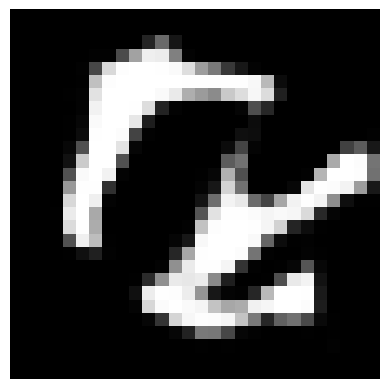

Epoch: 2/40, gLoss: 0.66, dLoss: 0.7


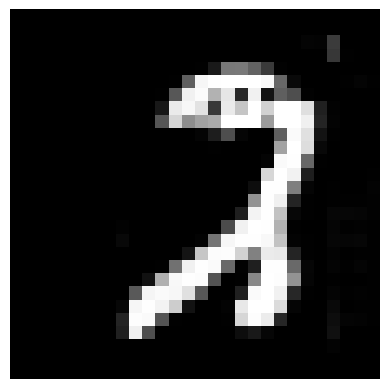

Epoch: 3/40, gLoss: 0.68, dLoss: 0.69


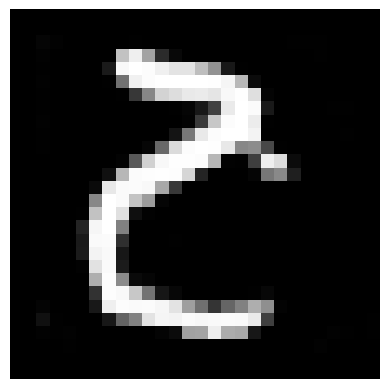

Epoch: 4/40, gLoss: 0.69, dLoss: 0.69


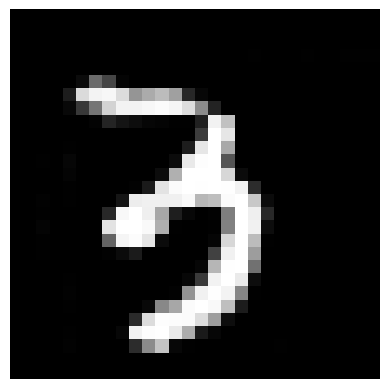

Epoch: 5/40, gLoss: 0.69, dLoss: 0.69


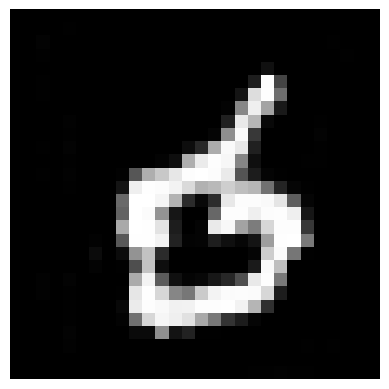

Epoch: 6/40, gLoss: 0.69, dLoss: 0.69


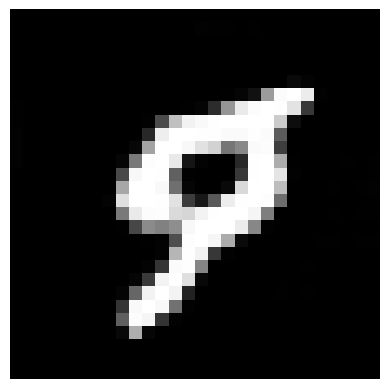

Epoch: 7/40, gLoss: 0.69, dLoss: 0.69


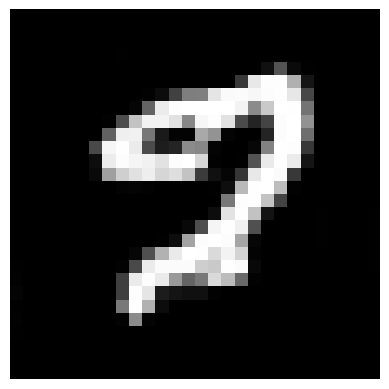

Epoch: 8/40, gLoss: 0.69, dLoss: 0.69


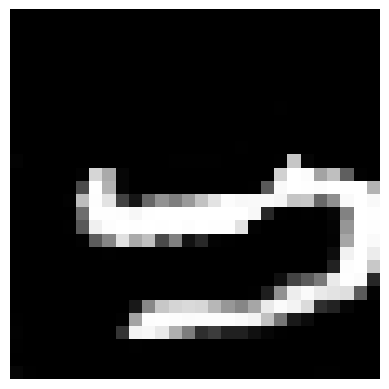

Epoch: 9/40, gLoss: 0.69, dLoss: 0.69


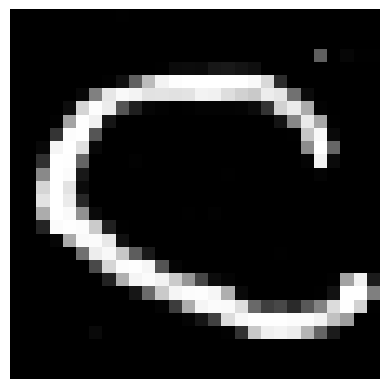

Epoch: 10/40, gLoss: 0.69, dLoss: 0.69


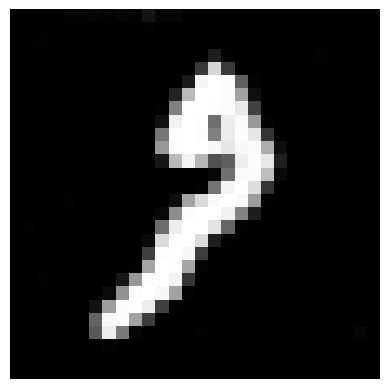

Epoch: 11/40, gLoss: 0.69, dLoss: 0.69


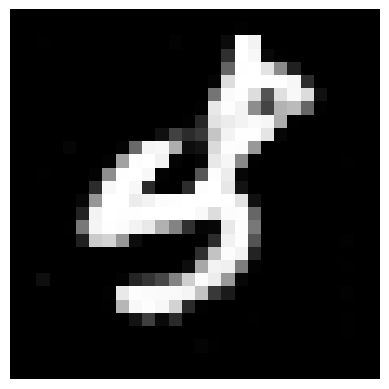

Epoch: 12/40, gLoss: 0.69, dLoss: 0.69


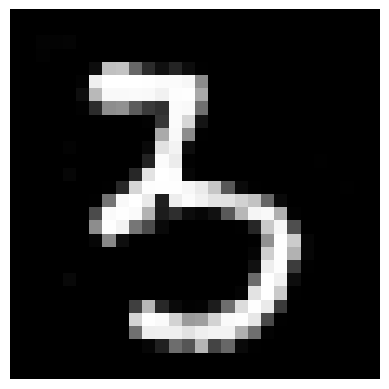

Epoch: 13/40, gLoss: 0.69, dLoss: 0.69


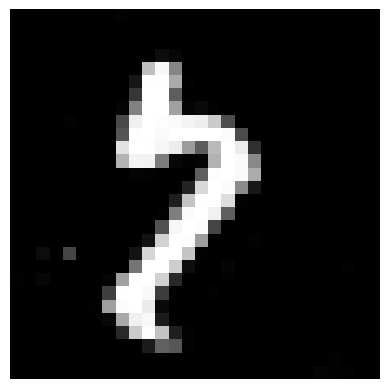

Epoch: 14/40, gLoss: 0.69, dLoss: 0.69


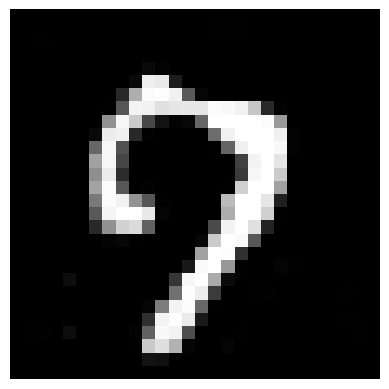

Epoch: 15/40, gLoss: 0.69, dLoss: 0.69


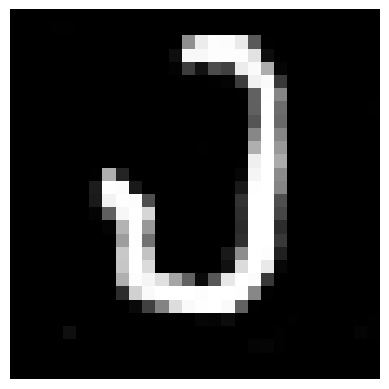

Epoch: 16/40, gLoss: 0.69, dLoss: 0.69


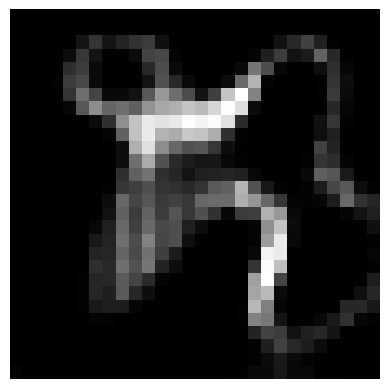

Epoch: 17/40, gLoss: 0.69, dLoss: 0.69


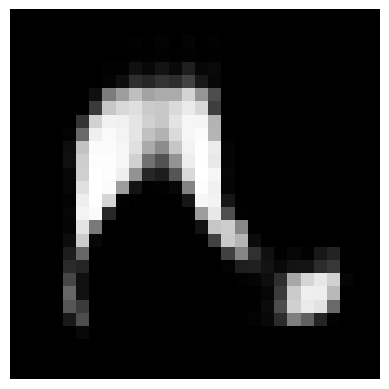

Epoch: 18/40, gLoss: 0.69, dLoss: 0.69


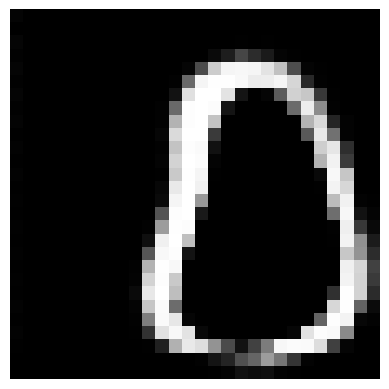

Epoch: 19/40, gLoss: 0.69, dLoss: 0.69


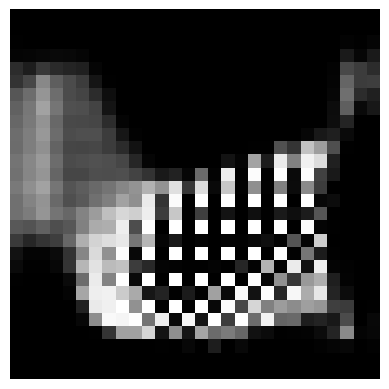

Epoch: 20/40, gLoss: 0.69, dLoss: 0.69


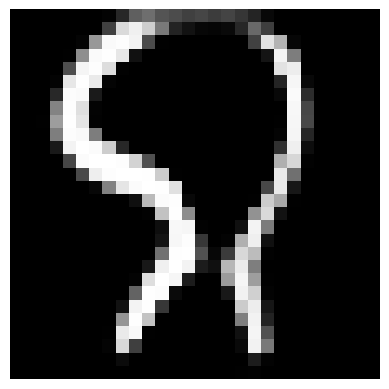

Epoch: 21/40, gLoss: 0.69, dLoss: 0.69


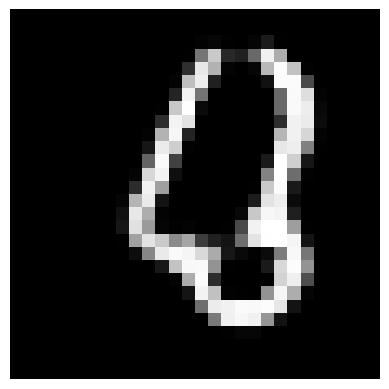

Epoch: 22/40, gLoss: 0.69, dLoss: 0.69


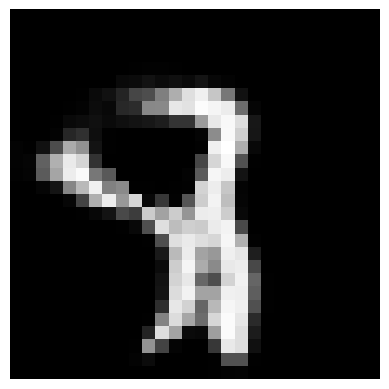

Epoch: 23/40, gLoss: 0.69, dLoss: 0.69


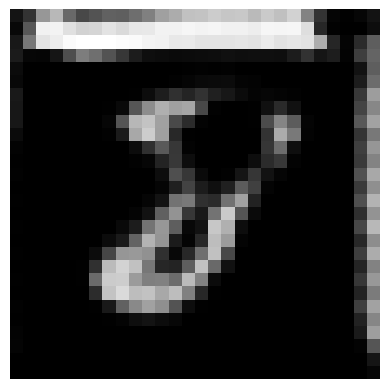

Epoch: 24/40, gLoss: 0.69, dLoss: 0.69


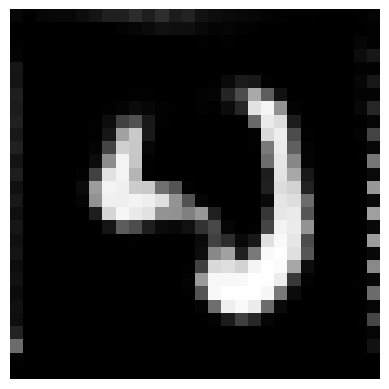

Epoch: 25/40, gLoss: 0.69, dLoss: 0.69


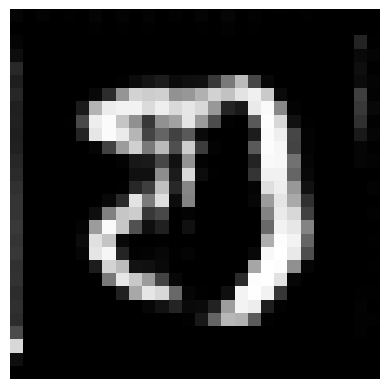

Epoch: 26/40, gLoss: 0.69, dLoss: 0.69


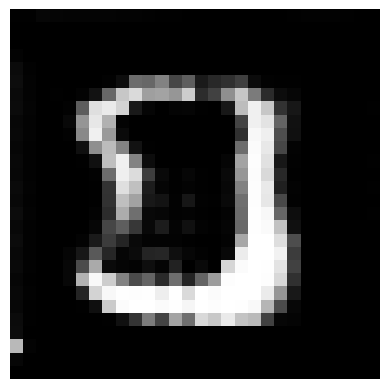

Epoch: 27/40, gLoss: 0.69, dLoss: 0.69


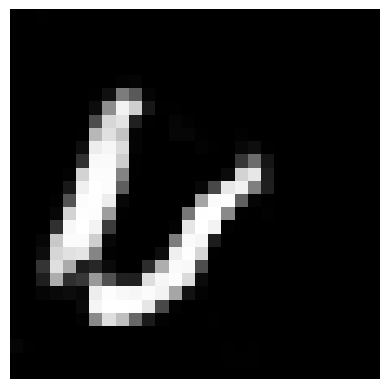

Epoch: 28/40, gLoss: 0.69, dLoss: 0.69


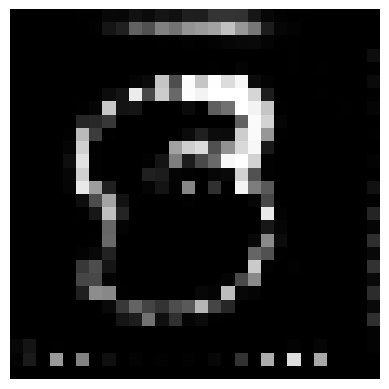

Epoch: 29/40, gLoss: 0.69, dLoss: 0.69


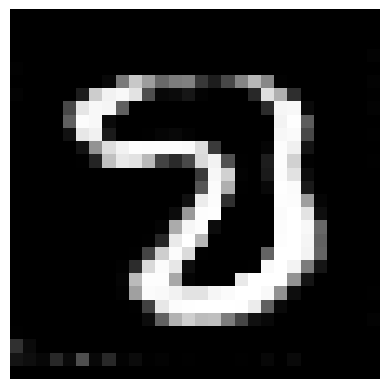

Epoch: 30/40, gLoss: 0.69, dLoss: 0.69


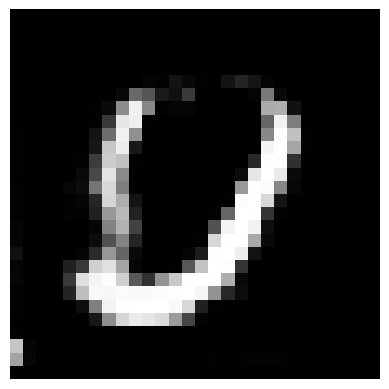

In [ ]:
for epoch in range(epochs):
  totalgLoss = 0.0
  totaldLoss = 0.0
  iteration = 0

  for images,_ in dataloader:
    images = images.to(device)

    trueLabels = torch.full((images.size(0), 1),0.9).to(device)
    fakeLabels = torch.zeros(images.size(0), 1).to(device)

    randomNoise = torch.randn(images.size(0), 100, 1, 1).to(device)

    fakeImages = generator(randomNoise)

    dRLoss = criteria(discriminator(images), trueLabels)
    dFLoss = criteria(discriminator(fakeImages.detach()), fakeLabels)

    dLoss = (dRLoss + dFLoss)/2
    totaldLoss += dLoss.item()

    dOptimizer.zero_grad()
    dLoss.backward()
    dOptimizer.step()

    randomNoise = torch.randn(images.size(0), 100, 1, 1).to(device)

    op = generator(randomNoise)

    gLoss = criteria(discriminator(op), trueLabels)
    totalgLoss += gLoss.item()

    gOptimizer.zero_grad()
    gLoss.backward()
    gOptimizer.step()

    iteration +=1
  print(f"Epoch: {epoch+1}/{epochs}, gLoss: {(totalgLoss/iteration):.2}, dLoss: {(totaldLoss/iteration):.2}")

  with torch.no_grad():
    test_noise = torch.randn(1, 100, 1, 1, device=device)
    op = generator(test_noise)

    img = op[0].detach().cpu()
    img = (img + 1) / 2

    plt.imshow(img.squeeze(), cmap='gray')

    plt.axis('off')
    plt.show()
